### Rain-on-snow project <br>
#### Definition of ROS zone and events accross NE US

In [1]:
import sys
# Path to ROS functions
sys.path.append('/users/m/m/mmorale3/netfiles/ciroh/mmorales/ROS_project/ros-workflow')

In [2]:
import os
import functions.rain_on_snow_fncns as ros
from functions.rain_on_snow_fncns import nwm_proj
import geopandas
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

In [3]:
from dask.distributed import Client
client = Client()
#clien = Client(n_workers=6, memory_limit='2GB') 
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 251.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42951,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44669,Total threads: 4
Dashboard: http://127.0.0.1:35347/status,Memory: 62.80 GiB
Nanny: tcp://127.0.0.1:39569,


1. Load NWM data

In [4]:
# Path to AWS NWM retrospective data
s3_path = 's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/ldasout.zarr'
#timerange_test = slice('2019-01-01 00:00:00','2020-12-31 18:00:00')
timerange_test = slice('1979-10-01 00:00:00','2022-09-30 18:00:00')
variables = ["SNEQV", "QRAIN"]

In [5]:
%%time
ds_ne = ros.read_nwmData(awsPath = s3_path, variables = variables, timerange = timerange_test)

CPU times: user 1.37 s, sys: 173 ms, total: 1.54 s
Wall time: 3.63 s


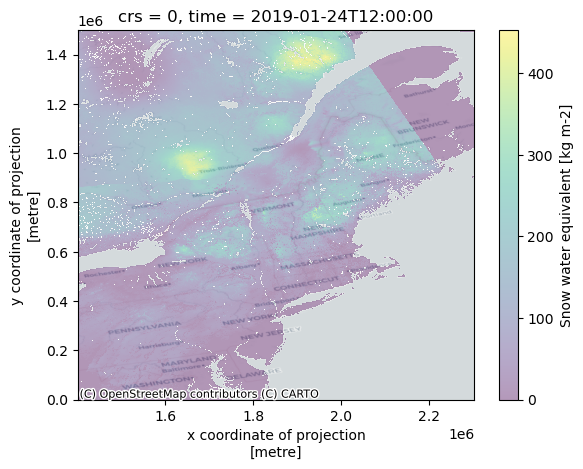

In [6]:
# Let's plot one time slice
timerange = slice('2019-01-24 12:00:00','2019-01-24 12:00:00')
#ds_sub2 = ds_sub.sel(time=timerange).QRAIN.persist() 
ds_sub2 = ds_ne.sel(time=timerange).SNEQV.persist() 

fig, axs = plt.subplots()
ds_sub2.plot(ax=axs, alpha=0.4)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

2. Get ROS daily mask with Musselman method

In [7]:
%%time
ros_daily_mask = ros.ros_musselman(ds_ne)

CPU times: user 2.02 s, sys: 113 ms, total: 2.14 s
Wall time: 2.16 s


In [ ]:
#ros_daily_mask

In [ ]:
# Let'd pick a day for testing
test_ros = ros_daily_mask.isel(time=360)
fig, axs = plt.subplots()
test_ros.plot(ax=axs, alpha=0.4)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

3. Define ROS zone

In [ ]:
%%time
# The threshold for the full retrospective period should be 43 
# For testing with 2 years, set to 2
ros_zone = ros.define_ros_zone(daily_ros_mask = ros_daily_mask, threshold = 43)

/users/m/m/mmorale3/.conda/envs/rosEnv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 3min 18s, sys: 22.7 s, total: 3min 41s
Wall time: 18min 54s


4. Get ROS zone basins from GAGES II 

In [9]:
# Create a directory to save outputs and get ID for ros zone/events identified based on GAGES II basins
saveDir = './output'
os.makedirs(saveDir, exist_ok=True)

In [10]:
# Load GAGES II basins
shpPath = '~/netfiles/ciroh/mmorales/ROS_project/shapefiles/GAGES_II/boundaries_shapefiles_by_aggeco/boundaries-shapefiles-by-aggeco/'
fname_ref = 'bas_ref_all.shp'
fname_nonref = 'bas_nonref_NorthEast.shp'

shapefile_ref = f'{shpPath}{fname_ref}'
shapefile_nonref = f'{shpPath}{fname_nonref}'

In [11]:
# Prepares basins shapefile in the NWM projection and subsets them to the domain extension
ref_bsns_shp = ros.prepare_spatial_assets(ds = ds_ne, shp_path = shapefile_ref)
nonref_bsns_shp = ros.prepare_spatial_assets(ds = ds_ne, shp_path = shapefile_nonref)

Automatic Setup Complete: 304 basins selected.
Automatic Setup Complete: 609 basins selected.


In [12]:
shp_dict = {
    "gagesii_bsn_ref": ref_bsns_shp,
    "gagesii_bsn_nonref": nonref_bsns_shp
}

* For time testing purposes

In [13]:
%%time
# For time testing purposes

# The function will return a dataframe with the basins and % of grid cells within the ROS zone
ros_zone_ref_bsns = ros.get_ros_basins(ros_zone = ros_zone, shp = ref_bsns_shp)

CPU times: user 2.49 s, sys: 55.4 ms, total: 2.54 s
Wall time: 2.54 s


In [14]:
ros_zone_ref_bsns.head()

,GAGE_ID,Perc_ROS
3,01021480,8.0
5,01022330,20.0
6,01022500,13.0
7,01023000,31.0
10,01030500,14.0


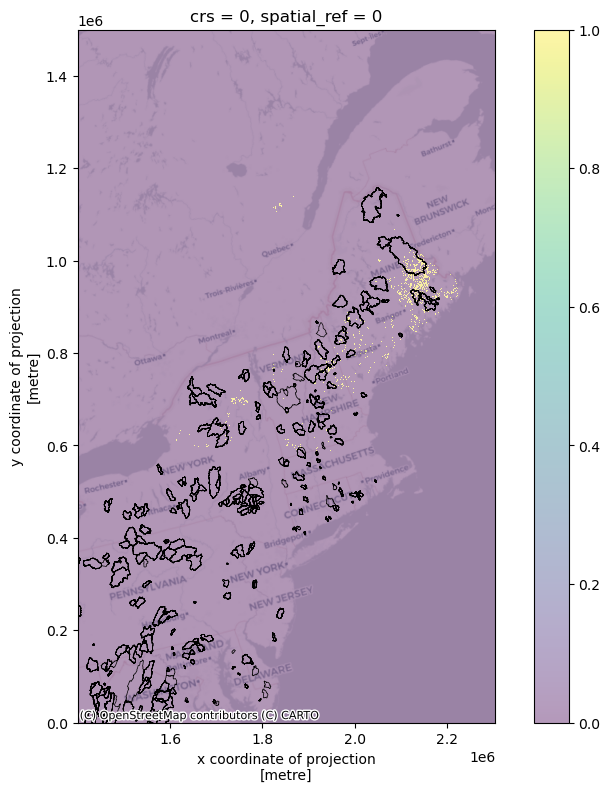

In [15]:
# Let's take a look at the basins and ros zone
#shp = geopandas.read_file(shpPath, layer='bas_ref_all')
#shp_prj = shp.to_crs(nwm_proj.crs)

fig, axs = plt.subplots(figsize=(10, 9))
ros_zone.plot(ax=axs, alpha=0.4)
ref_bsns_shp.plot(ax=axs,cmap=None,facecolor="none", edgecolor='k',linewidth=0.5)
cx.add_basemap(axs, crs=nwm_proj.crs, source=cx.providers.CartoDB.Positron)

* Processing all GAGES II basins at once

In [16]:
%%time
results = []

for name, shp in shp_dict.items():
    df = ros.get_ros_basins(ros_zone = ros_zone, shp = shp)
    
    df.to_csv(f"{saveDir}/ros_zone_{name}.csv", index=False)
    df.to_parquet(f'{saveDir}/ros_zone_{name}.parquet', index=False)
    
    results.append(df)

ros_zone_all = pd.concat(results, ignore_index=True)

CPU times: user 13 s, sys: 191 ms, total: 13.1 s
Wall time: 13.2 s


In [20]:
len(ros_zone_all['GAGE_ID'].unique())

137

In [ ]:
# Let's export the full dataset into a csv and parquet file
ros_zone_all.to_csv(f'{saveDir}/ros_zone_all_gagesii.csv', index=False)
ros_zone_all.to_parquet(f'{saveDir}/ros_zone_all_gagesii.parquet', index=False)

5. Extract ROS events for the provided basins

- For time testing purposes

In [22]:
%%time
ros_events_ref_bsns = ros.batch_processor(ds = ros_daily_mask, func = ros.get_ros_events, batch_size_years = 5, shp = ref_bsns_shp)

--- Processing 1979 to 1983 ---
--- Processing 1984 to 1988 ---
--- Processing 1989 to 1993 ---
--- Processing 1994 to 1998 ---
--- Processing 1999 to 2003 ---
--- Processing 2004 to 2008 ---
--- Processing 2009 to 2013 ---
--- Processing 2014 to 2018 ---
--- Processing 2019 to 2022 ---
CPU times: user 8min 13s, sys: 1min 35s, total: 9min 49s
Wall time: 26min 47s


In [23]:
ros_events_ref_bsns.head()

,GAGE_ID,Date,Perc_ROS
0,01611500,1979-10-10,1.3
1,01630700,1979-10-10,1.9
2,01632000,1979-10-10,0.4
3,01632900,1979-10-10,8.8
4,01634500,1979-10-10,0.6


* Processing all GAGES II basins at once

In [24]:
%%time
results = []

for name, shp in shp_dict.items():

    print(f'Processing {name}...')
    df = ros.batch_processor(ds = ros_daily_mask, func = ros.get_ros_events, batch_size_years = 5, shp = shp)
    
    df.to_csv(f"{saveDir}/ros_events_{name}.csv", index=False)
    df.to_parquet(f'{saveDir}/ros_events_{name}.parquet', index=False)
    
    results.append(df)

ros_events_all = pd.concat(results, ignore_index=True)

Processing gagesii_bsn_ref...
--- Processing 1979 to 1983 ---
--- Processing 1984 to 1988 ---
--- Processing 1989 to 1993 ---
--- Processing 1994 to 1998 ---
--- Processing 1999 to 2003 ---
--- Processing 2004 to 2008 ---
--- Processing 2009 to 2013 ---
--- Processing 2014 to 2018 ---
--- Processing 2019 to 2022 ---
Processing gagesii_bsn_nonref...
--- Processing 1979 to 1983 ---
--- Processing 1984 to 1988 ---
--- Processing 1989 to 1993 ---
--- Processing 1994 to 1998 ---
--- Processing 1999 to 2003 ---
--- Processing 2004 to 2008 ---
--- Processing 2009 to 2013 ---
--- Processing 2014 to 2018 ---
--- Processing 2019 to 2022 ---
CPU times: user 20min 25s, sys: 3min 9s, total: 23min 34s
Wall time: 57min 19s


In [25]:
# Let's export them into a csv and parquet file
ros_events_all.to_csv(f'{saveDir}/ros_events_all_gagesii.csv', index=False)
ros_events_all.to_parquet(f'{saveDir}/ros_events_all_gagesii.parquet', index=False)

In [ ]:
client.shutdown()